In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pickle
import scipy.stats as stats
from scipy.stats import genextreme, genpareto

In [20]:
# 1. Membaca data dari file Excel
file_path = "Data Curah Hujan Harian Cleaned.xlsx"  # Path ke file Excel
data = pd.read_excel(file_path, header=0)  # Membaca data dari file Excel
print(data)

        Tanggal  Curah Hujan
0    2022-01-01         36.0
1    2022-01-02         59.4
2    2022-01-03          3.5
3    2022-01-04          1.7
4    2022-01-05         99.5
...         ...          ...
1091 2024-12-27          2.5
1092 2024-12-28          4.5
1093 2024-12-29          3.0
1094 2024-12-30         10.0
1095 2024-12-31         81.0

[1096 rows x 2 columns]


In [21]:
# 4. Mengonversi 'Curah Hujan' menjadi numerik
data['Curah Hujan'] = pd.to_numeric(data['Curah Hujan'], errors='coerce')  # Mengonversi nilai curah hujan menjadi numerik

# 5. Mengonversi 'Tanggal' menjadi format datetime
data['Tanggal'] = pd.to_datetime(data['Tanggal'], errors='coerce')  # Mengonversi kolom Tanggal menjadi format datetime

In [ ]:
# 10. Menyiapkan data untuk ELM (Extreme Learning Machine)
for i in range(1, 6):  # Membuat lag 1 hingga lag 10
    data[f'RR-{i}'] = data['Curah Hujan'].shift(i)  # Menambahkan lag untuk fitur

# 11. Menghapus baris yang memiliki nilai kosong setelah pembuatan fitur lag
data.dropna(subset=[f'RR-{i}' for i in range(1, 6)], inplace=True)  # Menghapus baris dengan nilai kosong setelah lag

# 12. Menentukan fitur (RR-1 hingga RR-10) dan target ('Curah Hujan')
X = data[[f'RR-{i}' for i in range(1, 6)]].values  # Fitur untuk prediksi (lag 1 hingga lag 10)
y = data['Curah Hujan'].values  # Target adalah curah hujan saat ini

In [23]:
# pd.DataFrame(y, columns=['Curah Hujan']).to_csv('curah_hujan_target.csv', index=False)
# pd.DataFrame(X, columns=[f'RR-{i}' for i in range(1, 3)]).to_csv('curah_hujan_fitur.csv', index=False)

In [24]:
train_ratio = 0.8
train_size = int(len(X) * train_ratio)
print("Jumlah Data Latih:", train_size)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print("Jumlah Data Uji:", len(X_test))

Jumlah Data Latih: 874
Jumlah Data Uji: 219


In [25]:
# 14. Membuat kelas Extreme Learning Machine (ELM)
class ELM:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size  # Ukuran input
        self.hidden_size = hidden_size  # Ukuran hidden layer
        self.output_size = output_size  # Ukuran output
        # Bobot input dan bias diinisialisasi secara acak
        self.weights = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.biases = np.random.uniform(-1, 1, (1, hidden_size))
        self.output_weights = np.random.uniform(-1, 1, (hidden_size, output_size))  # Bobot output

    def relu_activation(self, x):
        return np.maximum(0, x)  # Fungsi aktivasi ReLU

    def train(self, X, y):
        # Menghitung output dari hidden layer dengan fungsi aktivasi ReLU
        H = self.relu_activation(np.dot(X, self.weights) + self.biases)
        H_pseudo_inv = np.linalg.pinv(H)  # Invers Moore-Penrose
        self.output_weights = np.dot(H_pseudo_inv, y)  # Menghitung bobot output

    def predict(self, X):
        # Menghitung output untuk data uji
        H = self.relu_activation(np.dot(X, self.weights) + self.biases)
        predictions = np.dot(H, self.output_weights)
        return np.maximum(predictions, 0)  # Mengembalikan prediksi, memastikan output tidak negatif

In [26]:
# 15. Menentukan model ELM terbaik berdasarkan MAE dan MSE
best_mae = float('inf')  # Menetapkan nilai awal MAE terbaik
best_mse = float('inf')  # Menetapkan nilai awal MSE terbaik

best_hidden_size_mae = None  # Menyimpan ukuran hidden layer terbaik untuk MAE
best_hidden_size_mse = None  # Menyimpan ukuran hidden layer terbaik untuk MSE

best_elm_mae = None  # Menyimpan model ELM terbaik untuk MAE
best_elm_mse = None  # Menyimpan model ELM terbaik untuk MSE

mae_scores_for_hidden_sizes = []  # Menyimpan nilai MAE untuk setiap ukuran hidden layer
mse_scores_for_hidden_sizes = []  # Menyimpan nilai MSE untuk setiap ukuran hidden layer

# 16. Melakukan eksperimen dengan berbagai ukuran hidden layer
hidden_sizes = [1, 3, 5, 10, 15, 20, 25, 30]  # Daftar ukuran hidden layer yang akan diuji

In [27]:
for hidden_size in hidden_sizes:
    elm = ELM(input_size=X_train.shape[1], hidden_size=hidden_size, output_size=1)  # Membuat model ELM dengan ukuran hidden layer yang diuji
    elm.train(X_train, y_train)  # Melatih model dengan data pelatihan
    predictions = elm.predict(X_test)  # Menggunakan model untuk memprediksi data uji

    # Menghitung MAE dan MSE
    mae = mean_absolute_error(y_test, predictions)  # Mean Absolute Error (MAE)
    mse = mean_squared_error(y_test, predictions)  # Mean Squared Error (MSE)
    
    # Menyimpan hasil perhitungan MAE dan MSE untuk setiap ukuran hidden layer
    mae_scores_for_hidden_sizes.append(mae)
    mse_scores_for_hidden_sizes.append(mse)
    
    # Melacak model terbaik berdasarkan MAE
    if mae < best_mae:
        best_mae = mae
        best_hidden_size_mae = hidden_size
        best_elm_mae = elm

    # Melacak model terbaik berdasarkan MSE
    if mse < best_mse:
        best_mse = mse
        best_hidden_size_mse = hidden_size
        best_elm_mse = elm

    # Mencetak hasil sementara untuk debugging
    print(f"Jumlah Neuron pada Hidden Layer: {hidden_size}")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")

# 17. Menampilkan hasil terbaik berdasarkan MAE dan MSE
print(f"Best MAE: {best_mae} untuk Jumlah Neuron: {best_hidden_size_mae}")
print(f"Best MSE: {best_mse} untuk Jumlah Neuron: {best_hidden_size_mse}")

Jumlah Neuron pada Hidden Layer: 1
MAE: 5.924657534246576
MSE: 276.0056164383562
Jumlah Neuron pada Hidden Layer: 3
MAE: 6.493245086821831
MSE: 248.41793498880583
Jumlah Neuron pada Hidden Layer: 5
MAE: 5.9576066078378425
MSE: 245.1558743913029
Jumlah Neuron pada Hidden Layer: 10
MAE: 7.688426690652551
MSE: 219.0287772010797
Jumlah Neuron pada Hidden Layer: 15
MAE: 6.699647789533959
MSE: 221.04783757030418
Jumlah Neuron pada Hidden Layer: 20
MAE: 6.93823487635679
MSE: 229.33778747153607
Jumlah Neuron pada Hidden Layer: 25
MAE: 7.39172897065818
MSE: 231.07616370872856
Jumlah Neuron pada Hidden Layer: 30
MAE: 6.79637507424174
MSE: 210.20518998431385
Best MAE: 5.924657534246576 untuk Jumlah Neuron: 1
Best MSE: 210.20518998431385 untuk Jumlah Neuron: 30


In [10]:
# 18. Plot prediksi dan data aktual
best_predictions = best_elm_mae.predict(X_test)  # Menggunakan model ELM terbaik berdasarkan MAE

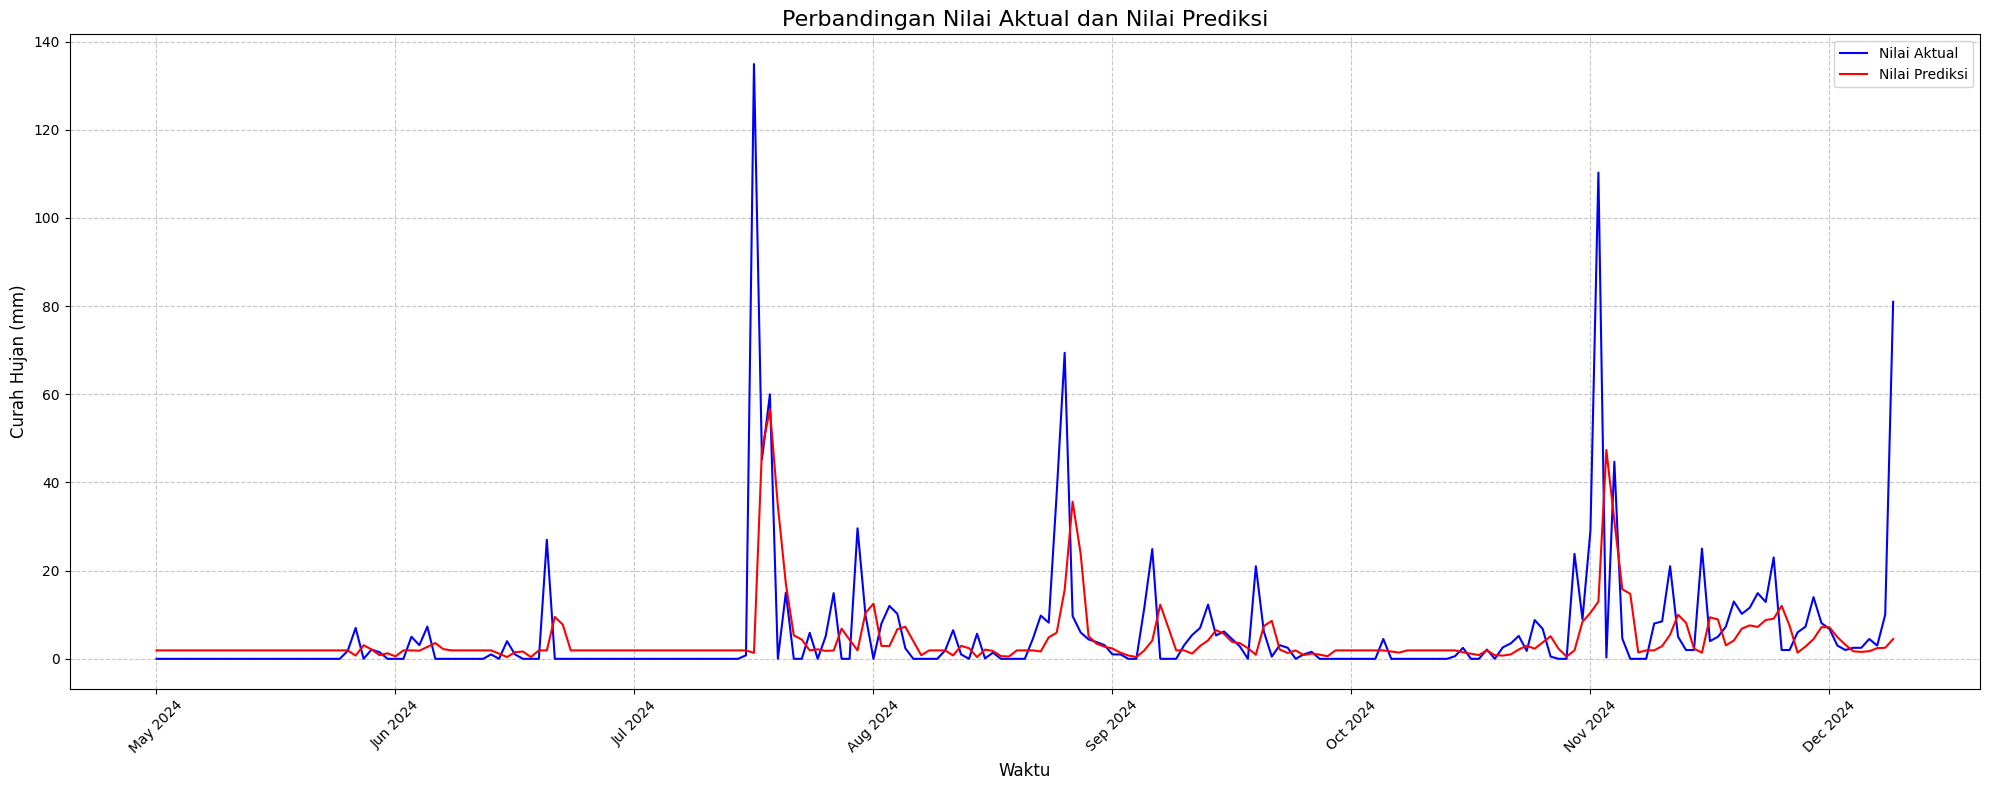

MAE for Best ELM model: 5.868186384266101
MSE for Best ELM model: 221.6459160566857


In [11]:
# Plot the actual vs predicted rainfall for the best ELM model (using MAE)
plt.figure(figsize=(20, 8))

# Plot actual data (blue)
plt.plot(y_test, color='blue', label='Nilai Aktual')

# Plot predictions (red) for the best ELM model
plt.plot(best_predictions, color='red', label='Nilai Prediksi')


# Adding title and labels
plt.title('Perbandingan Nilai Aktual dan Nilai Prediksi', fontsize=16)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)

# Adding Year-Month labels on the X-axis (every 6 months)
dates = data['Tanggal'].iloc[-len(y_test):]  # Ambil tanggal sesuai jumlah data uji
years_months = dates.dt.strftime('%b %Y')  # Format bulan dan tahun

# Display each label per 6 data (to reduce density)
plt.xticks(ticks=np.arange(0, len(dates), step=30), labels=years_months[::30], rotation=45, fontsize=10)

# Adding legend and grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# 19. Menampilkan kinerja model terbaik (MAE, MSE)
print(f"MAE for Best ELM model: {best_mae}")
print(f"MSE for Best ELM model: {best_mse}")

Text(0.5, 1.0, 'Perbandingan MAE untuk Jumlah Neuron yang Berbeda')

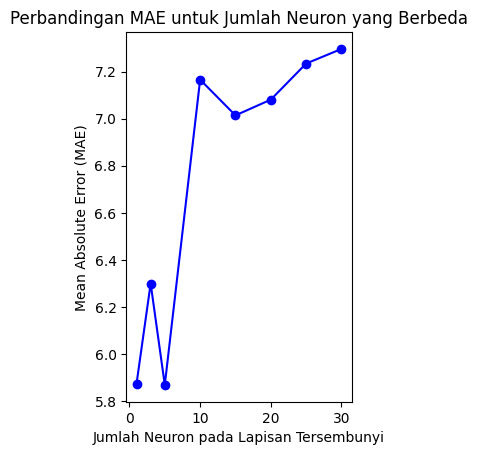

In [12]:
# 20. Grafik MAE dan MSE untuk perbandingan
plt.subplot(1, 2, 1)
plt.plot(hidden_sizes, mae_scores_for_hidden_sizes, marker='o', color='blue')
plt.xlabel('Jumlah Neuron pada Lapisan Tersembunyi')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Perbandingan MAE untuk Jumlah Neuron yang Berbeda')

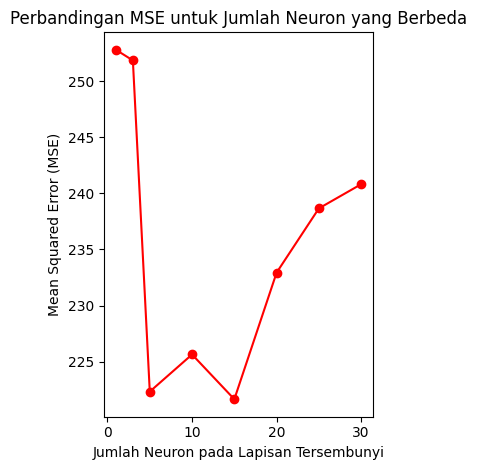

In [13]:
# 21. Grafik MSE
plt.subplot(1, 2, 2)
plt.plot(hidden_sizes, mse_scores_for_hidden_sizes, marker='o', color='red')
plt.xlabel('Jumlah Neuron pada Lapisan Tersembunyi')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Perbandingan MSE untuk Jumlah Neuron yang Berbeda')

plt.tight_layout()
plt.show()

In [14]:
# Menyimpan model ELM terbaik berdasarkan MAE
with open('best_elm_model_mae.pkl', 'wb') as file:
    pickle.dump(best_elm_mae, file)

# Menyimpan model ELM terbaik berdasarkan MSE
with open('best_elm_model_mse.pkl', 'wb') as file:
    pickle.dump(best_elm_mse, file)

print("Model ELM terbaik telah disimpan.")

Model ELM terbaik telah disimpan.


In [15]:
file_path = "Data Curah Hujan Harian Cleaned2.xlsx"  # Path ke file Excel
data = pd.read_excel(file_path, header=0)  # Membaca data dari file Excel

# Menambahkan kolom 'Bulan' yang terdiri dari Tahun dan Bulan
data['Bulan'] = data['Tanggal'].dt.to_period('M')

# Mengelompokkan berdasarkan bulan dan mencari nilai maksimum dari curah hujan per bulan
bulan_max = data.groupby('Bulan')['Curah Hujan'].max().reset_index()

# Menampilkan tabel baru "Bulan" yang berisi nilai maksimum curah hujan per bulan
print(bulan_max)

      Bulan  Curah Hujan
0   2022-01   117.000000
1   2022-02   144.000000
2   2022-03    76.500000
3   2022-04    32.000000
4   2022-05    32.500000
5   2022-06    78.000000
6   2022-07    40.500000
7   2022-08    66.500000
8   2022-09    40.500000
9   2022-10    58.500000
10  2022-11    89.600000
11  2022-12   126.400000
12  2023-01   130.000000
13  2023-02   200.000000
14  2023-03   112.500000
15  2023-04    45.000000
16  2023-05    37.800000
17  2023-06    20.000000
18  2023-07    66.000000
19  2023-08    26.000000
20  2023-09    25.500000
21  2023-10    39.000000
22  2023-11   126.000000
23  2023-12    29.500000
24  2024-01    75.000000
25  2024-02    24.100000
26  2024-03    50.500000
27  2024-04    47.500000
28  2024-05    31.000000
29  2024-06     7.300000
30  2024-07    27.000000
31  2024-08   134.900000
32  2024-09    69.400000
33  2024-10    21.000000
34  2024-11   110.300000
35  2024-12    81.000000
36  2025-01    35.765412


In [16]:
# 21. Fitting distribusi GEV pada data ekstrem
monthly_extremes = bulan_max['Curah Hujan'].values
params = stats.genextreme.fit(monthly_extremes)  # Fitting distribusi GEV
shape_gev, loc_gev, scale_gev = params  # Parameter distribusi GEV: shape, location, scale
# Menampilkan parameter distribusi GEV
print(f"GEV Parameters - Shape: {shape_gev}, Location: {loc_gev}, Scale: {scale_gev}")

# 22. Menguji kesesuaian distribusi dengan uji Kolmogorov-Smirnov
ks_stat, ks_p_value = stats.kstest(monthly_extremes, 'genextreme', args=params)  # Uji kesesuaian GEV

# 23. Menampilkan hasil uji kesesuaian
print(f"Kolmogorov-Smirnov Test Statistic: {ks_stat}, P-value: {ks_p_value}")

GEV Parameters - Shape: -0.24295919938967303, Location: 43.31948040476665, Scale: 27.928369609969188
Kolmogorov-Smirnov Test Statistic: 0.10299281575446395, P-value: 0.78982707068272


In [17]:
# Membagi data bulanan (blok) dan menguji distribusi GEV
for month, month_data in bulan_max.groupby('Bulan')['Curah Hujan']:
    # Fitting distribusi GEV untuk setiap bulan
    params_month = stats.genextreme.fit(month_data)
    shape_month, loc_month, scale_month = params_month
    
    # Uji Kolmogorov-Smirnov untuk distribusi GEV setiap bulan
    ks_stat_month, ks_p_value_month = stats.kstest(month_data, 'genextreme', args=params_month)

    # Menampilkan hasil uji kesesuaian GEV untuk bulan tertentu
    print(f"Bulan {month} - GEV KS Test - Statistic: {ks_stat_month}, P-value: {ks_p_value_month}")

c:\Users\muham\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_distn_infrastructure.py:409: RuntimeWarning: invalid value encountered in scalar divide
  return m3 / np.power(m2, 1.5)


Bulan 2022-01 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-02 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-03 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-04 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-05 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-06 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-07 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-08 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-09 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-10 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-11 - GEV KS Test - Statistic: 0.6321205588285577, P-value: 0.7357588823428847
Bulan 2022-12 - GEV K

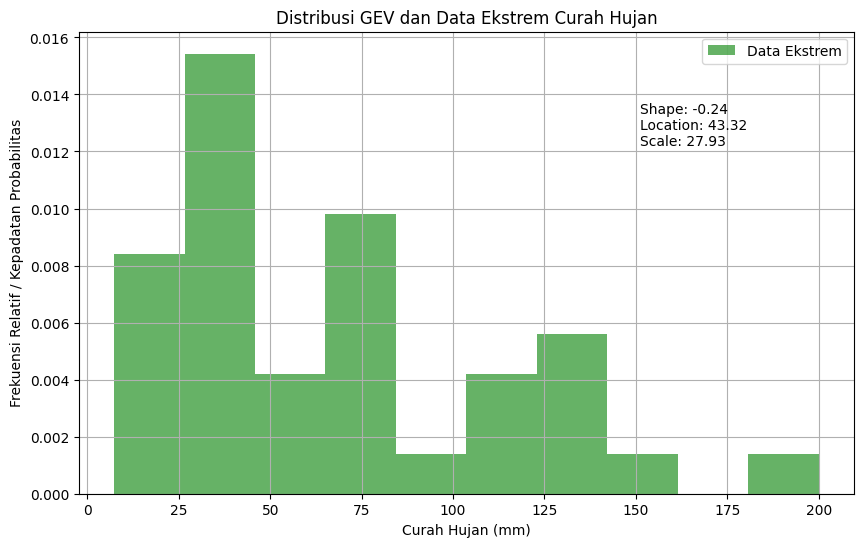

In [18]:
# 24. Plot histogram data ekstrem dan distribusi GEV
plt.figure(figsize=(10, 6))
plt.hist(monthly_extremes, bins=10, density=True, alpha=0.6, color='g', label='Data Ekstrem')


# 26. Plot distribusi GEV
plt.title('Distribusi GEV dan Data Ekstrem Curah Hujan')
plt.xlabel('Curah Hujan (mm)')
plt.ylabel('Frekuensi Relatif / Kepadatan Probabilitas')
plt.text(151, 0.0122, f'Shape: {shape_gev:.2f}\nLocation: {loc_gev:.2f}\nScale: {scale_gev:.2f}', fontsize=10)
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# 30. Fungsi untuk menghitung residual life (rata-rata data yang melebihi threshold)
def calculate_residual_life(threshold, data):
    # Ambil data yang lebih besar dari threshold
    exceedances = data[data > threshold]
    
    # Jika ada data yang melebihi threshold, hitung rata-rata residual life
    if len(exceedances) > 0:
        residual_life = np.mean(exceedances - threshold)  # Rata-rata data yang melebihi threshold
    else:
        residual_life = np.nan  # Jika tidak ada data yang melebihi threshold, beri NaN
    
    return residual_life

In [20]:
# 31. Tentukan rentang threshold yang ingin diuji
thresholds = np.linspace(min(monthly_extremes), max(monthly_extremes), 100)  # Membuat rentang threshold

residual_life_values = [calculate_residual_life(threshold, monthly_extremes) for threshold in thresholds]

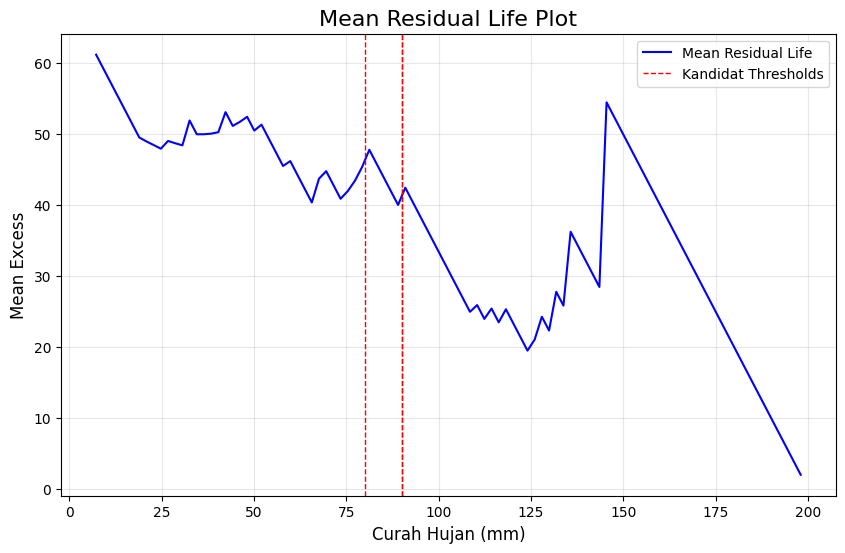

In [21]:
# Membuat plot residual life
plt.figure(figsize=(10, 6))
plt.plot(thresholds, residual_life_values, label="Mean Residual Life", color='blue')

thresholds_lines = [80, 90]
for threshold in thresholds_lines:
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1)
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1, label='Kandidat Thresholds')
# Menambahkan judul dan label
plt.title('Mean Residual Life Plot', fontsize=16)
plt.xlabel('Curah Hujan (mm)', fontsize=12)
plt.ylabel('Mean Excess', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [31]:
# 38. Threshold yang sudah ditentukan (110 mm)
threshold = 100  # Menentukan threshold untuk data ekstrem

# 39. Identifikasi nilai ekstrem yang lebih besar dari threshold
extreme_values = monthly_extremes[monthly_extremes > threshold]  # Mengambil data yang melebihi threshold

# 40. Menampilkan jumlah nilai ekstrem yang teridentifikasi
print(f"Jumlah nilai ekstrem (lebih besar dari threshold {threshold} mm): {len(extreme_values)}")  # Menampilkan jumlah nilai ekstrem
n_u = len(extreme_values)  # Jumlah nilai ekstrem
n = len(monthly_extremes)  # Jumlah total data

Jumlah nilai ekstrem (lebih besar dari threshold 100 mm): 9


In [32]:
# 41. Fitting distribusi Generalized Pareto Distribution (GPD) pada nilai ekstrem
params_gpd = stats.genpareto.fit(extreme_values)  # Fitting distribusi GPD pada data ekstrem
shape_gpd, loc_gpd, scale_gpd = params_gpd  # Menyimpan parameter distribusi GPD
loc_gpd = 100  # Menetapkan lokasi GPD sesuai threshold
# 42. Menampilkan parameter distribusi GPD
print(f"GPD Parameters - Shape: {shape_gpd}, Location: {loc_gpd}, Scale: {scale_gpd}")  # Menampilkan parameter GPD
# Uji Kolmogorov-Smirnov untuk distribusi GPD pada data ekstrem
ks_stat_gpd, ks_p_value_gpd = stats.kstest(extreme_values, 'genpareto', args=params_gpd)

# Menampilkan hasil uji kesesuaian GPD
print(f"Kolmogorov-Smirnov Test GPD - Statistic: {ks_stat_gpd}, P-value: {ks_p_value_gpd}")

GPD Parameters - Shape: -1.4640967792431479, Location: 100, Scale: 293.67185380383773
Kolmogorov-Smirnov Test GPD - Statistic: 0.4228533138601794, P-value: 0.05649577905688019


In [33]:
# 40. Fitting distribusi GEV untuk seluruh data ekstrem
params_extreme = stats.genextreme.fit(extreme_values)
shape_extreme, loc_extreme, scale_extreme = params_extreme

# 41. Uji Kolmogorov-Smirnov untuk setiap nilai ekstrem terhadap distribusi GEV
for value in extreme_values:
    ks_stat, ks_p_value = stats.kstest([value], 'genextreme', args=params_extreme)
    print(f"Nilai ekstrem: {value} mm - KS Test - Statistic: {ks_stat}, P-value: {ks_p_value}")

Nilai ekstrem: 117.0 mm - KS Test - Statistic: 0.740459374658442, P-value: 0.519081250683116
Nilai ekstrem: 144.0 mm - KS Test - Statistic: 0.796770307083378, P-value: 0.4064593858332439
Nilai ekstrem: 126.4 mm - KS Test - Statistic: 0.5434737505588596, P-value: 0.9130524988822808
Nilai ekstrem: 130.0 mm - KS Test - Statistic: 0.6193785964449571, P-value: 0.7612428071100859
Nilai ekstrem: 200.0 mm - KS Test - Statistic: 0.9586226121603093, P-value: 0.08275477567938139
Nilai ekstrem: 112.5 mm - KS Test - Statistic: 0.8950884533601313, P-value: 0.20982309327973736
Nilai ekstrem: 126.0 mm - KS Test - Statistic: 0.5339677263588027, P-value: 0.9320645472823945
Nilai ekstrem: 134.9 mm - KS Test - Statistic: 0.6989718961973688, P-value: 0.6020562076052625
Nilai ekstrem: 110.3 mm - KS Test - Statistic: 0.9527689622739898, P-value: 0.09446207545202046


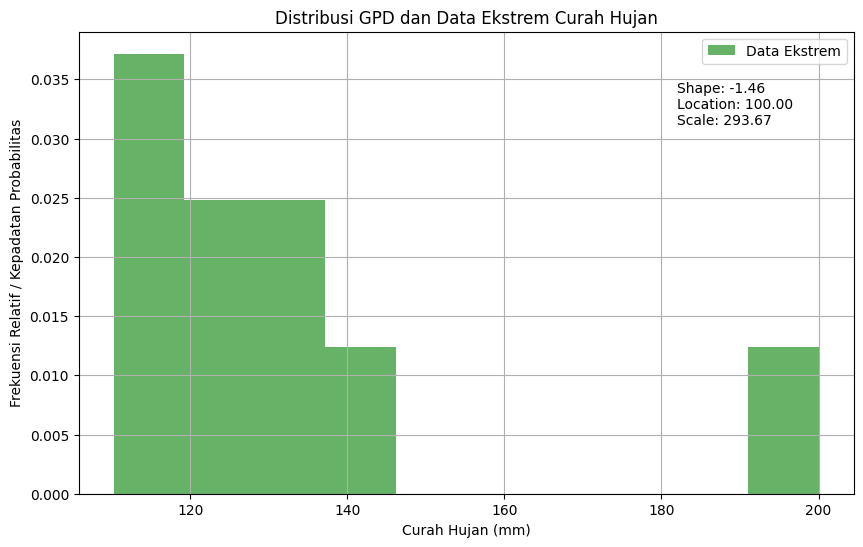

In [34]:
# 44. Plot histogram data ekstrem dan distribusi GPD
plt.figure(figsize=(10, 6))  # Menentukan ukuran plot

# 45. Histogram data ekstrem (gunakan extreme_values, bukan monthly_extremes)
plt.hist(extreme_values, bins=10, density=True, alpha=0.6, color='g', label='Data Ekstrem')  # Menampilkan histogram data ekstrem

# 46. Menambahkan label dan judul pada grafik
plt.title('Distribusi GPD dan Data Ekstrem Curah Hujan')  # Judul grafik
plt.xlabel('Curah Hujan (mm)')  # Label sumbu X
plt.ylabel('Frekuensi Relatif / Kepadatan Probabilitas')  # Label sumbu Y
plt.text(182, 0.0312, f'Shape: {shape_gpd:.2f}\nLocation: {loc_gpd:.2f}\nScale: {scale_gpd:.2f}', fontsize=10)
plt.legend()  # Menambahkan legenda
plt.grid(True)  # Menambahkan grid
plt.show()  # Menampilkan grafik

In [35]:
# 27. Fungsi untuk menghitung Value at Risk (VaR)
def calculate_var_gev(p, shape, loc, scale):
    # Menghitung VaR berdasarkan distribusi GEV atau GPD
    var = loc + (scale / shape) * ((-np.log(1 - p)) ** shape - 1)
    return var
def calculate_var_gpd(p, loc, scale, shape, n, n_u):
    # Menghitung VaR berdasarkan distribusi GPD
    x = (n / n_u) * (p)  # Penyesuaian untuk proporsi
    var = loc + (scale / shape) * ((x ** (shape)) - 1)
    return var

In [36]:
# 28. Menghitung VaR untuk masing-masing tingkat kepercayaan
confidence_levels = [0.90, 0.95, 0.99]

var_values_gev = []
for p in confidence_levels:
    var_gev = calculate_var_gev(p, shape_gev, loc_gev, scale_gev)
    var_values_gev.append(var_gev)
    print(f"VaR pada {int(p*100)}% kepercayaan dengan GEV: {var_gev}")

VaR pada 90% kepercayaan dengan GEV: 64.40428045975679
VaR pada 95% kepercayaan dengan GEV: 70.2178924109472
VaR pada 99% kepercayaan dengan GEV: 78.95255509534113


In [37]:
var_values_gpd = []
for p in confidence_levels:
    var_gpd = calculate_var_gpd(p, loc_gpd, scale_gpd, shape_gpd, n, n_u)
    var_values_gpd.append(var_gpd)
    print(f"VaR pada {int(p * 100)}% kepercayaan dengan GPD: {var_gpd}")

VaR pada 90% kepercayaan dengan GPD: 271.04364726151675
VaR pada 95% kepercayaan dengan GPD: 273.29176031758675
VaR pada 99% kepercayaan dengan GPD: 274.8908950393861


In [38]:
data_januari = np.array([117.0, 130.0, 75.0, 69.7])  # Januari 2022, 2023, 2024, 2025
data_februari = np.array([144.0, 200.0, 24.1, 62.1])  # Februari 2022, 2023, 2024, 2025
data_maret = np.array([76.5, 112.5, 50.5, 46.0])  # Maret 2022, 2023, 2024, 2025

In [39]:
# Fungsi untuk menghitung VaR
def calculate_var(p, shape, loc, scale):
    # VaR dihitung menggunakan rumus distribusi GEV atau GPD
    var = loc + scale * ((-np.log(1 - p)) ** shape - 1) / shape
    return var

# Fungsi untuk fitting distribusi GEV dan GPD serta menghitung VaR
def fit_and_calculate_var(data):
    # Fitting distribusi GEV
    params_gev = genextreme.fit(data)
    shape_gev, loc_gev, scale_gev = params_gev  # Mendapatkan parameter distribusi GEV

    # Fitting distribusi GPD
    params_gpd = genpareto.fit(data)
    shape_gpd, loc_gpd, scale_gpd = params_gpd  # Mendapatkan parameter distribusi GPD

    # Menghitung VaR pada berbagai tingkat kepercayaan
    confidence_levels = [0.90, 0.95, 0.99]

    # Menghitung VaR untuk GEV
    var_values_gev = []
    for p in confidence_levels:
        var_gev = calculate_var(p, shape_gev, loc_gev, scale_gev)
        var_values_gev.append(var_gev)
        print(f"VaR pada {int(p*100)}% kepercayaan dengan GEV: {var_gev}")

    # Menghitung VaR untuk GPD
    var_values_gpd = []
    for p in confidence_levels:
        var_gpd = calculate_var(p, shape_gpd, loc_gpd, scale_gpd)
        var_values_gpd.append(var_gpd)
        print(f"VaR pada {int(p*100)}% kepercayaan dengan GPD: {var_gpd}")

# Prediksi VaR untuk Januari, Februari, Maret
print("Prediksi VaR untuk Januari:")
fit_and_calculate_var(data_januari)

print("\nPrediksi VaR untuk Februari:")
fit_and_calculate_var(data_februari)

print("\nPrediksi VaR untuk Maret:")
fit_and_calculate_var(data_maret)

Prediksi VaR untuk Januari:
VaR pada 90% kepercayaan dengan GEV: 71.44515718991559
VaR pada 95% kepercayaan dengan GEV: 71.4485101867668
VaR pada 99% kepercayaan dengan GEV: 71.44921990277766
VaR pada 90% kepercayaan dengan GPD: 111.52481490837054
VaR pada 95% kepercayaan dengan GPD: 120.04890838692242
VaR pada 99% kepercayaan dengan GPD: 126.37930516067026

Prediksi VaR untuk Februari:
VaR pada 90% kepercayaan dengan GEV: 26.09880974618763
VaR pada 95% kepercayaan dengan GEV: 26.104182364616065
VaR pada 99% kepercayaan dengan GEV: 26.105475107606917
VaR pada 90% kepercayaan dengan GPD: 154.21124805217636
VaR pada 95% kepercayaan dengan GPD: 171.344400803189
VaR pada 99% kepercayaan dengan GPD: 186.67660618881854

Prediksi VaR untuk Maret:
VaR pada 90% kepercayaan dengan GEV: 47.14204492813051
VaR pada 95% kepercayaan dengan GEV: 47.14447882687458
VaR pada 99% kepercayaan dengan GEV: 47.14501465833631
VaR pada 90% kepercayaan dengan GPD: 94.11972480836683
VaR pada 95% kepercayaan denga